In [18]:
# Import our tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [19]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [20]:
df=sns.load_dataset('flights')
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [21]:
df.info

<bound method DataFrame.info of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>

In [22]:
df.isnull()

,year,month,passengers
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
139,False,False,False
140,False,False,False
141,False,False,False
142,False,False,False


In [23]:
df.isnull().sum()

year          0
month         0
passengers    0
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [25]:
df['month'].unique

<bound method Series.unique of 0      Jan
1      Feb
2      Mar
3      Apr
4      May
      ... 
139    Aug
140    Sep
141    Oct
142    Nov
143    Dec
Name: month, Length: 144, dtype: category
Categories (12, object): ['Jan', 'Feb', 'Mar', 'Apr', ..., 'Sep', 'Oct', 'Nov', 'Dec']>

In [26]:
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [27]:
# Map month names to numbers
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3,
    'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9,
    'Oct': 10, 'Nov': 11, 'Dec': 12
}

df['month'] = df['month'].map(month_map)

# Verify
df.head()

,year,month,passengers
0,1949,1,112
1,1949,2,118
2,1949,3,132
3,1949,4,129
4,1949,5,121


In [28]:
# x = everything except passengers (Our features)
# y = passengers (what we want to predict)

X = df.drop(columns=['passengers'])
Y = df['passengers']

print('X shape:',X.shape)
print('Y shape:',Y.shape)

X shape: (144, 2)
Y shape: (144,)


In [29]:
# split data into train and test

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=7)

print('Training Set:', X_train.shape)
print('Test Set:', X_test.shape)

Training Set: (115, 2)
Test Set: (29, 2)


In [40]:
# Create Random Forest Regression model

model = RandomForestRegressor(n_estimators=150, random_state=7)

# Train

model.fit(X_train, Y_train)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [41]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [42]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 17.95
MSE: 475.99
RMSE: 21.82
R² Score: 0.95


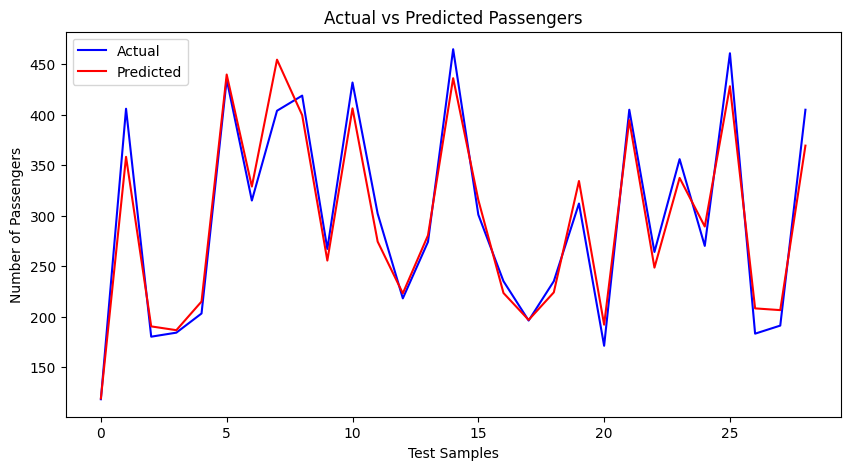

In [44]:
plt.figure(figsize=(10,5))
plt.plot(Y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title('Actual vs Predicted Passengers')
plt.xlabel('Test Samples')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

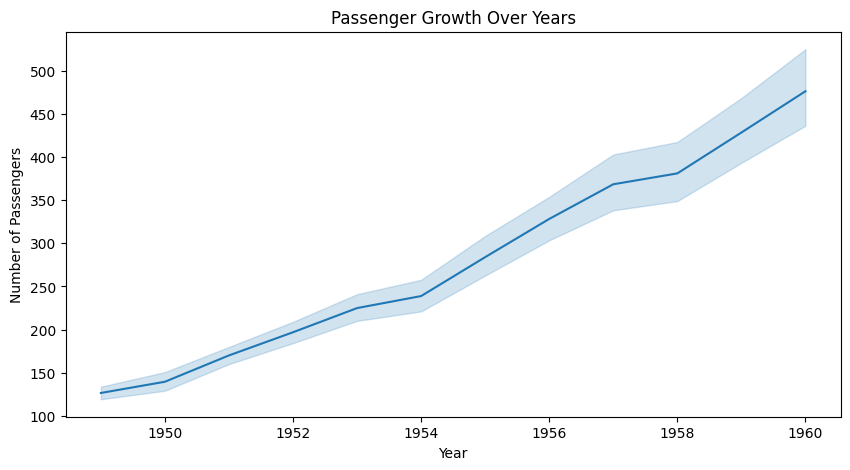

In [45]:
plt.figure(figsize=(10,5))
sns.lineplot(x='year', y='passengers', data=df)
plt.title('Passenger Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

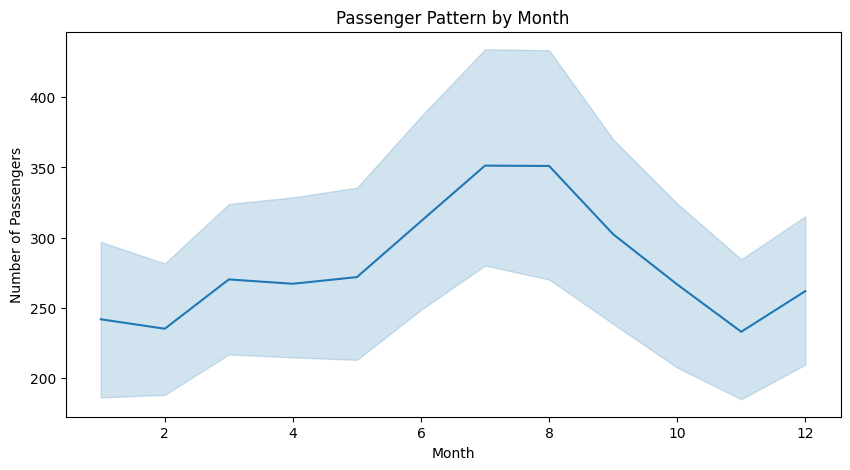

In [46]:
plt.figure(figsize=(10,5))
sns.lineplot(x='month', y='passengers', data=df)
plt.title('Passenger Pattern by Month')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.show()

In [47]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances)

year     0.875795
month    0.124205
dtype: float64
